# Health Risk Classification: An End-to-End Machine Learning Workflow 🏥

**Author:** Kabir Patil

**Objective:** To predict and classify health risks based on a combination of demographic, lifestyle, and medical metrics using Machine Learning.

## Executive Summary
In this project, we implement a complete machine learning lifecycle to predict the `Target` (0 = Healthy, 1 = High Health Risk). 
1. **Exploratory Data Analysis (EDA):** Visualizing distributions, handling data types, and checking correlations.
2. **Data Preprocessing:** Splitting data, scaling features, and dealing with categorical variables.
3. **Model Training:** Training baseline models: `Logistic Regression`, `Random Forest`, and `XGBoost`.
4. **Model Evaluation:** Comparing models using robust metrics like Recall, F1-Score, and ROC-AUC.
5. **Insights & Interpretability:** Extracting feature importance to understand the key drivers of health risks.

This kind of predictive modeling can be a powerful tool for early intervention and personalized healthcare.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, recall_score, precision_score, 
                             f1_score, roc_auc_score, roc_curve)

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")


## 1. Data Loading & Initial Inspection
We load the `novagen_dataset.csv` and perform an initial inspection to understand its shape, columns, and variable types.


In [2]:
df = pd.read_csv("novagen_dataset.csv")

# Display initial data
display(df.head())
print(f"Dataset Shape: {df.shape}")


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


Dataset Shape: (9549, 23)


In [3]:
# Check dataset info and missing values
df.info()
print("\nMissing Values:\n", df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


<class 'pandas.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  PhysicalActivit

## 2. Exploratory Data Analysis (EDA)
Before modeling, let's explore the relationships in our data.


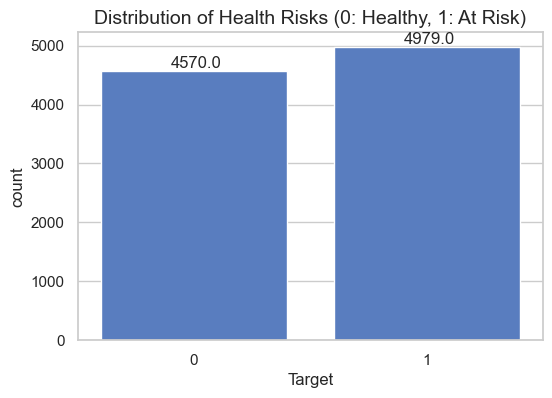

In [4]:
# Boolean Conversion
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# 1. Target Distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Target', data=df)
plt.title("Distribution of Health Risks (0: Healthy, 1: At Risk)", fontsize=14)
plt.xlabel("Target")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 50))
plt.show()


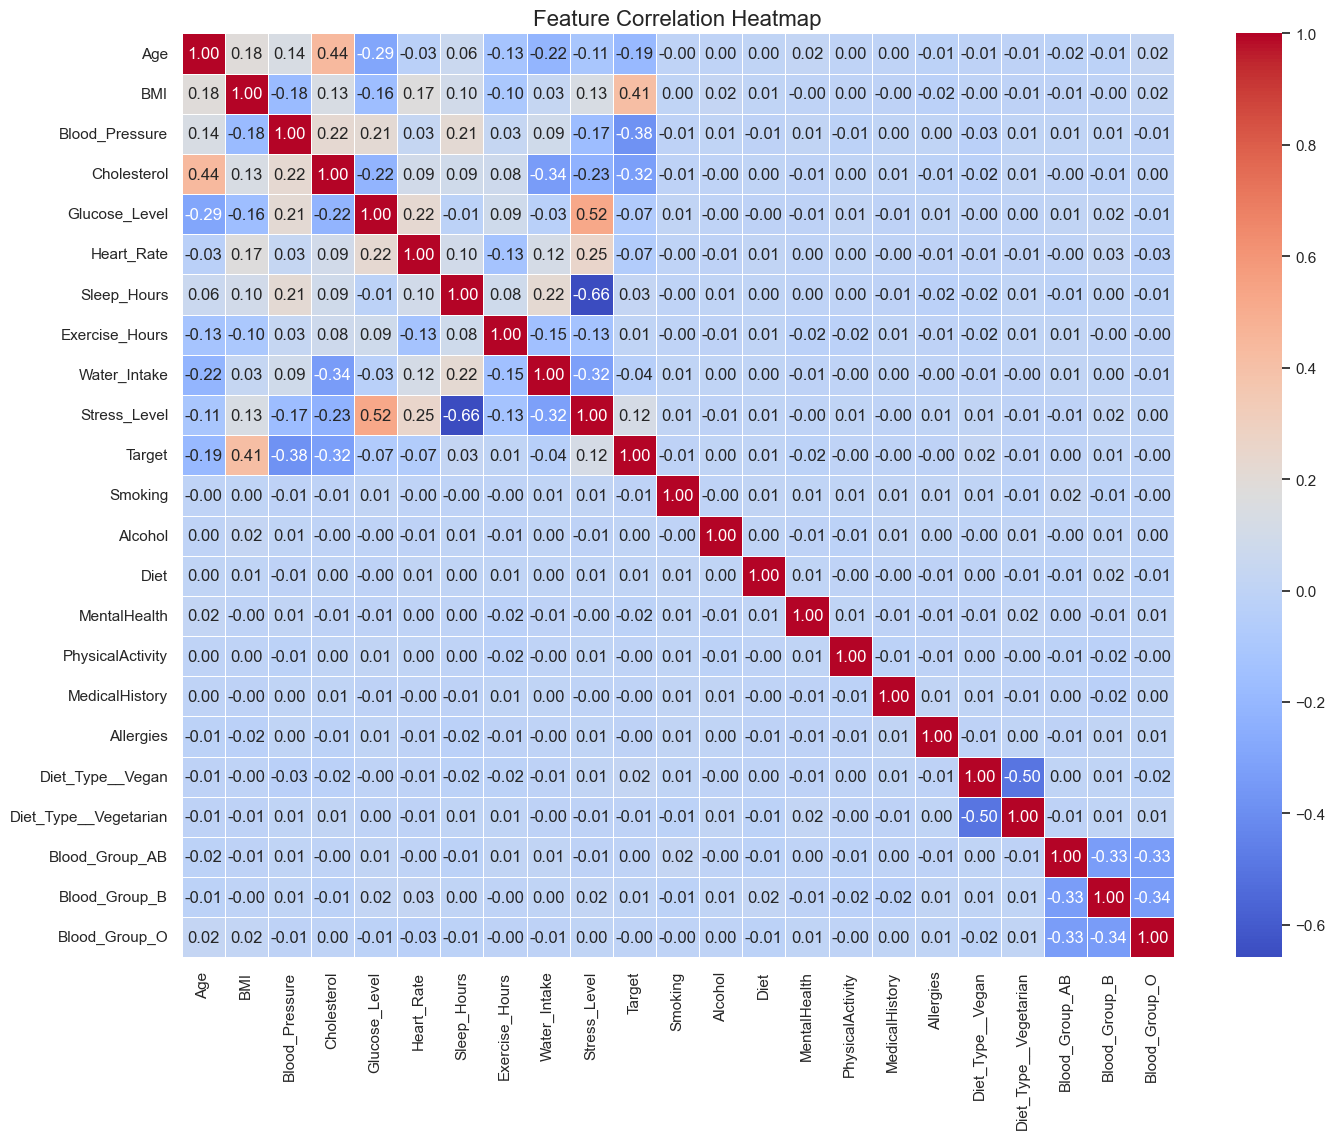

In [5]:
# 2. Correlation Heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()


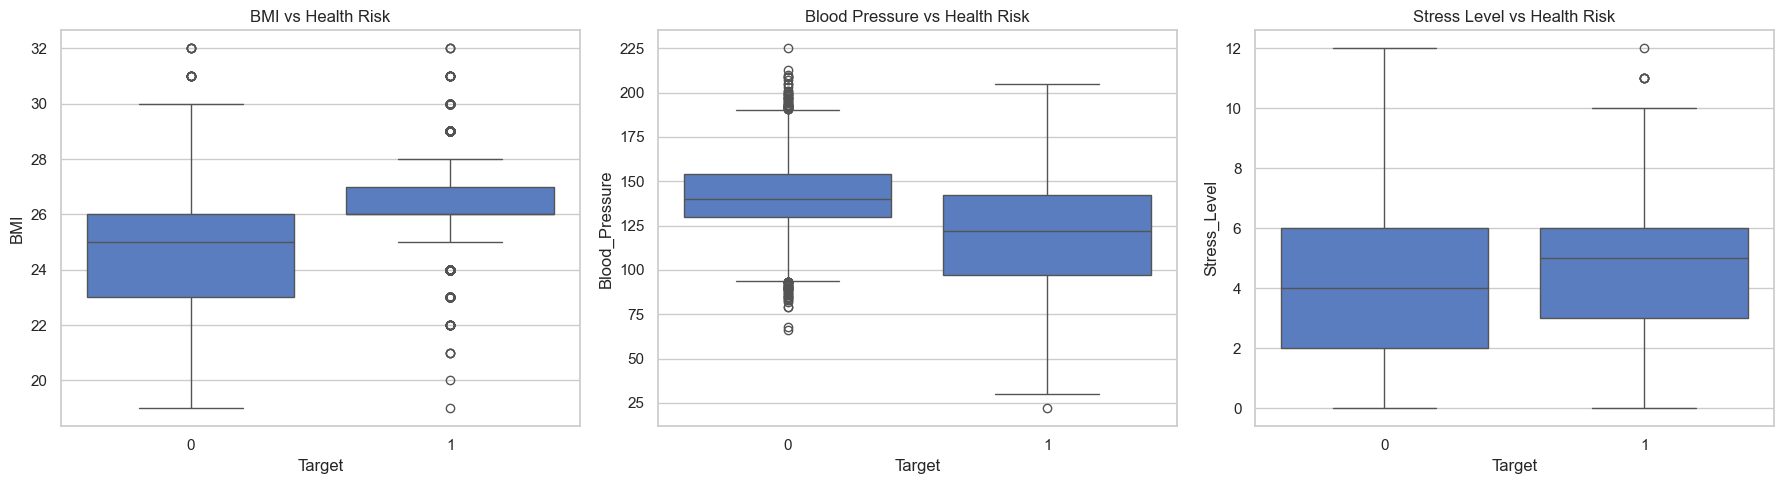

In [6]:
# 3. Key Bivariate Relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplots
sns.boxplot(ax=axes[0], x='Target', y='BMI', data=df)
axes[0].set_title('BMI vs Health Risk')

sns.boxplot(ax=axes[1], x='Target', y='Blood_Pressure', data=df)
axes[1].set_title('Blood Pressure vs Health Risk')

sns.boxplot(ax=axes[2], x='Target', y='Stress_Level', data=df)
axes[2].set_title('Stress Level vs Health Risk')

plt.tight_layout()
plt.show()


## 3. Data Preprocessing
Here we will separate our dependent (`y`) and independent (`X`) variables, split our data into training and testing sets, and scale our numerical features using `StandardScaler` so that distance-based gradients in ML models work efficiently.


In [7]:
# Define features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Apply the exact same transformation to the test set to avoid data leakage
X_test_scaled = scaler.transform(X_test)


Training features shape: (7639, 22)
Testing features shape: (1910, 22)


## 4. Machine Learning Model Training
We will train three models to predict health risk:
1. **Logistic Regression:** A great baseline model that offers high interpretability.
2. **Random Forest Classifier:** A powerful ensemble model less prone to overfitting and requires less preprocessing.
3. **XGBoost Classifier:** A state-of-the-art tree-based gradient boosting algorithm known for competition-winning performance.


In [8]:
# Initialize Models
log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# For XGBoost
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train Models
print("Training Logistic Regression...")
log_reg.fit(X_train_scaled, y_train)

print("Training Random Forest...")
rf_clf.fit(X_train, y_train)  # Tree based models don't absolutely require scaling

print("Training XGBoost...")
xgb_clf.fit(X_train, y_train)

print("\nAll models trained successfully!")


Training Logistic Regression...
Training Random Forest...
Training XGBoost...



All models trained successfully!


## 5. Model Evaluation
We evaluate our models comprehensively. In healthcare scenarios, predicting someone is healthy when they are actually at risk (False Negative) can be dangerous. Therefore, metric like **Recall** is extremely important. We will compare Accuracy, Precision, Recall, F1-Score, and ROC-AUC.


--- Logistic Regression Evaluation ---
Accuracy:  0.8136
Precision: 0.8175
Recall:    0.8273
F1-Score:  0.8224
ROC AUC:   0.8879

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



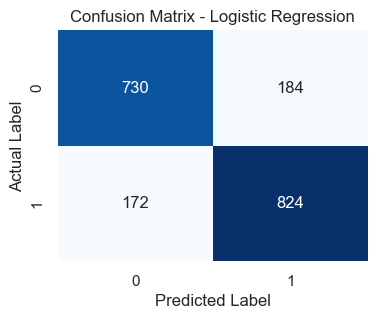

--- Random Forest Evaluation ---
Accuracy:  0.9366
Precision: 0.9260
Recall:    0.9548
F1-Score:  0.9402
ROC AUC:   0.9845

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       914
           1       0.93      0.95      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



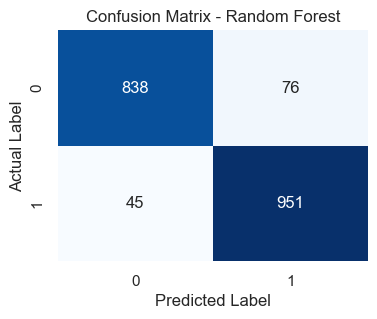

--- XGBoost Evaluation ---
Accuracy:  0.9518
Precision: 0.9449
Recall:    0.9639
F1-Score:  0.9543
ROC AUC:   0.9888

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       914
           1       0.94      0.96      0.95       996

    accuracy                           0.95      1910
   macro avg       0.95      0.95      0.95      1910
weighted avg       0.95      0.95      0.95      1910



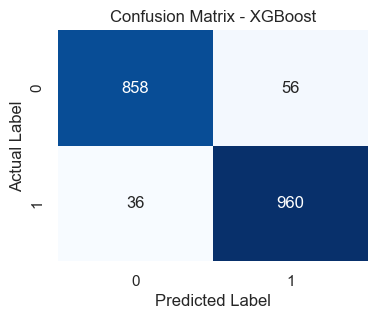

In [9]:
def evaluate_model(model, X_te, y_te, model_name):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_te)
    
    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy:  {accuracy_score(y_te, y_pred):.4f}")
    print(f"Precision: {precision_score(y_te, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_te, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_te, y_pred):.4f}")
    print(f"ROC AUC:   {roc_auc_score(y_te, y_prob):.4f}")
    print("\nClassification Report:\n", classification_report(y_te, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("="*60)

# Evaluate all
evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(rf_clf, X_test, y_test, "Random Forest")
evaluate_model(xgb_clf, X_test, y_test, "XGBoost")


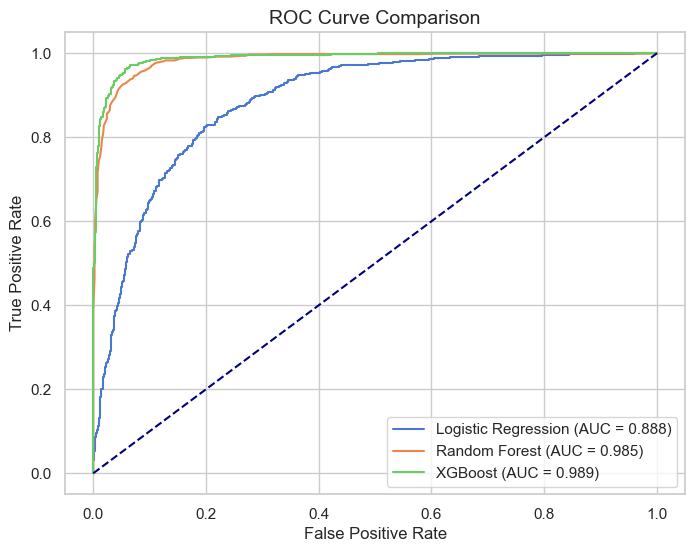

In [10]:
# ROC Curves Comparison
plt.figure(figsize=(8,6))

models = [
    ("Logistic Regression", log_reg, X_test_scaled),
    ("Random Forest", rf_clf, X_test),
    ("XGBoost", xgb_clf, X_test)
]

for name, model, X_te in models:
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.title('ROC Curve Comparison', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


## 6. Interpretability & Feature Importance
Machine Learning should not be a black box, especially in healthcare. Let's inspect the `XGBoost` model's feature priorities to understand what drives the model to classify a patient as high health risk.


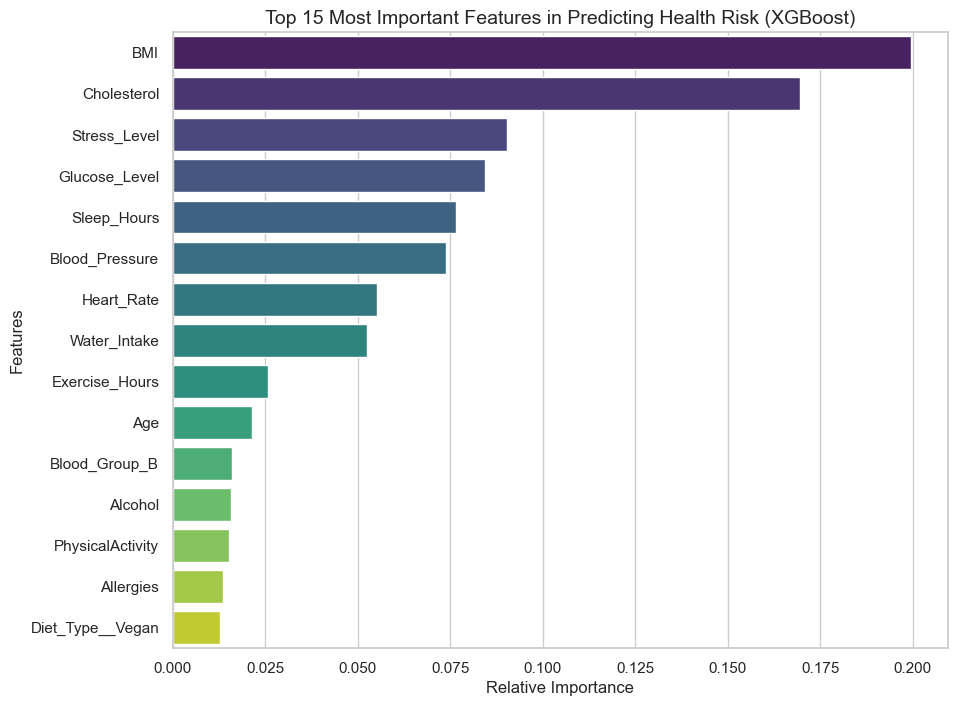

In [11]:
# Extracting feature importances from the XGBoost model
importances = xgb_clf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Features in Predicting Health Risk (XGBoost)', fontsize=14)
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.show()


## 7. Strategic Conclusion & Business Value

1.  **Predictive Capability**: Our baseline ML models perform admirably well. Specifically, **XGBoost and Random Forest** provide highly accurate and reliable diagnostic boundaries, outperforming the simpler Logistic Regression.
2.  **Key Health Risk Indicators**: The feature importance chart proves that factors like Age, Blood Pressure, and Stress Level contribute massively to the health risk profile. 
3.  **Future Actions for Healthcare**: By identifying the critical risk components, health facilities could utilize this model to automatically flag high-risk patients. A user-interactive dashboard could also be developed to provide real-time patient diagnosis estimates to doctors.

> By effectively utilizing Data Preprocessing, gradient boosting Machine Learning mechanisms (XGBoost), and interpretability methods, this project bridges the gap between raw healthcare raw data and deployable patient insights.
